# Day 4 — EDA Part 2: Relationships
### Real Estate Machine · Graduation Project

**Goal today:** stop looking at variables one at a time and start asking how they move *together*.

Yesterday told us the shape of each column. Today answers the question the business actually
cares about: **what drives price?**

---

### What you should be able to answer at the end of today

1. What are the top 5 price drivers, and what is the evidence for each?
2. Which pairs of features say almost the same thing? (multicollinearity)
3. Why is a raw group median often the wrong answer to "does X increase price?"
4. Which cities and zip codes give the most house per dollar?

> **Defense questions you are preparing for:** *"What is your strongest predictor?"* ·
> *"You say condition raises price — did you check whether older houses are just in better areas?"*

> ⚠️ **The rule for today:** correlation is not causation, and a difference between two group
> medians is not an effect. Every claim below gets stress-tested before it goes in the report.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = Path("..") / "Data"
FIGS = Path("..") / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

def save(fig, name):
    path = FIGS / f"{name}.png"
    fig.savefig(path)
    print("saved ->", path)

df = pd.read_csv(DATA / "data_clean.csv", parse_dates=["date"])
df["log_price"] = np.log(df["price"])
print("Shape:", df.shape)
df[["price", "sqft_living", "price_per_sqft", "city", "zipcode"]].head(3)

Shape: (4345, 22)


,price,sqft_living,price_per_sqft,city,zipcode
0,"313,000.00",1340,233.58,Shoreline,98133
1,"2,384,000.00",3650,653.15,Seattle,98119
2,"342,000.00",1930,177.20,Kent,98042


---
## 2. The correlation heatmap

Correlation measures **linear** association only, on a −1 to +1 scale. It is the fastest way to
see the whole picture, and the easiest thing in EDA to over-interpret. We read it carefully.

saved -> ../reports/figures/04_correlation_heatmap.png


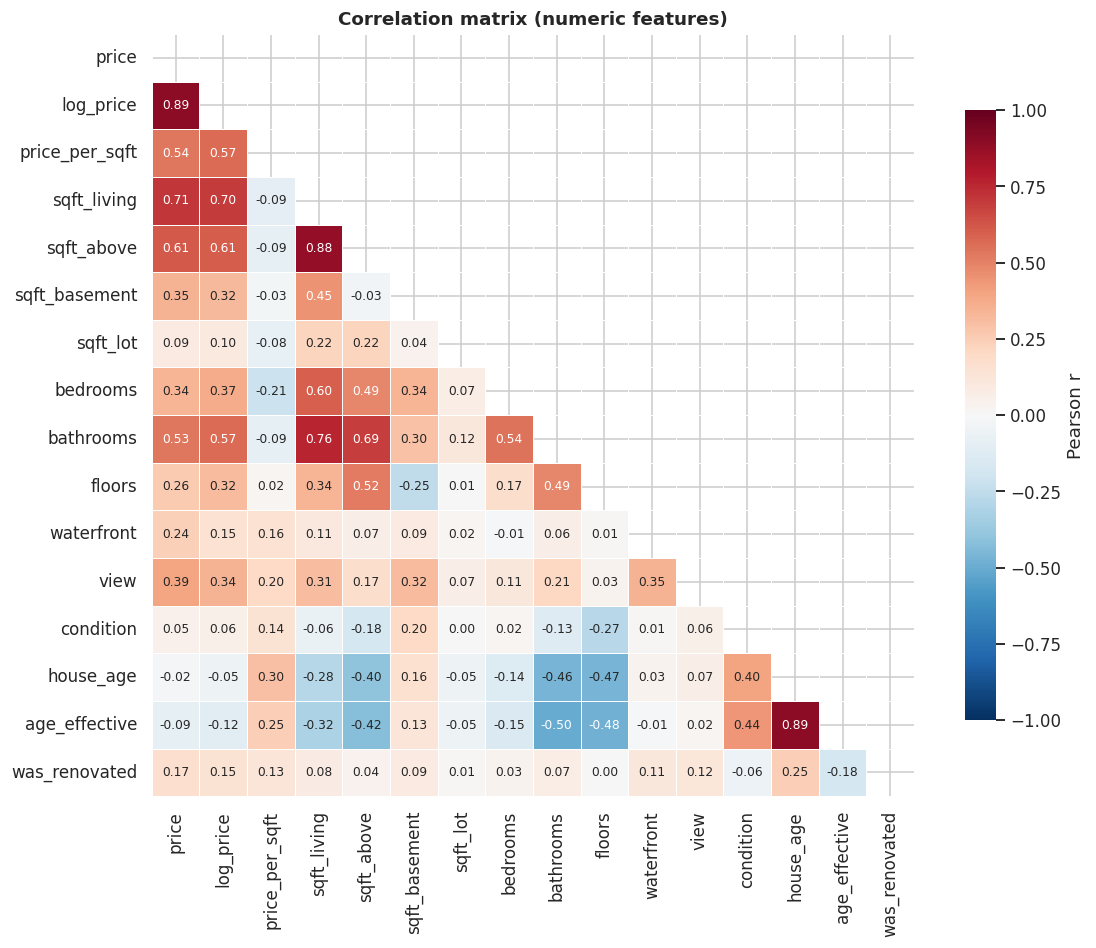

In [2]:
num_cols = ["price", "log_price", "price_per_sqft", "sqft_living", "sqft_above", "sqft_basement",
            "sqft_lot", "bedrooms", "bathrooms", "floors", "waterfront", "view", "condition",
            "house_age", "age_effective", "was_renovated"]

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .8, "label": "Pearson r"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlation matrix (numeric features)")

save(fig, "04_correlation_heatmap")
plt.show()

In [3]:
ranked = (corr["price"].drop(["price", "log_price", "price_per_sqft"])
          .sort_values(key=abs, ascending=False)
          .to_frame("corr_with_price"))
ranked["corr_with_log_price"] = corr["log_price"]
ranked.round(3)

,corr_with_price,corr_with_log_price
sqft_living,0.71,0.70
sqft_above,0.61,0.61
bathrooms,0.53,0.57
view,0.39,0.34
sqft_basement,0.34,0.32
bedrooms,0.34,0.37
floors,0.26,0.32
waterfront,0.24,0.15
was_renovated,0.17,0.15
age_effective,-0.09,-0.12


### Reading the ranking

**`sqft_living` at r ≈ 0.71 is the clear winner** and nothing else is close. Squaring it gives
r² ≈ 0.51 — living area alone explains about half the variance in price. That is your baseline:
any model that cannot beat "bigger house costs more" is not earning its keep.

**`sqft_above` (0.61) and `bathrooms` (0.53) look like independent runners-up. They are not.**
Both are largely proxies for size — we prove that in the next section.

**`condition` at r ≈ 0.05 looks like it does not matter.** That conclusion is wrong, and section 7
shows why. Correlation on a confounded variable can be near zero even when a real effect exists.

**Correlations with `log_price` are mostly slightly higher** than with raw price — further support
for yesterday's decision to model the log.

> **A limitation to state out loud:** Pearson r sees straight lines only. A variable with a
> genuine U-shaped relationship to price will show r ≈ 0. `house_age` is precisely that case
> (section 8). Never conclude "no relationship" from a low correlation alone.

---
## 3. Multicollinearity — features that repeat each other

Two features that carry the same information do not add information; they split it. For linear
models this destabilises the coefficients (large, opposite-signed, and unstable across folds) and
makes any "which feature matters" story unreliable.

We find every pair with |r| > 0.7 before it becomes a Day 9 problem.

In [4]:
pairs = (corr.drop(index=["price", "log_price", "price_per_sqft"],
                   columns=["price", "log_price", "price_per_sqft"])
         .where(np.triu(np.ones(corr.shape[0] - 3, dtype=bool), k=1))
         .stack()
         .rename("r")
         .reset_index()
         .rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))

strong = pairs[pairs["r"].abs() > 0.7].sort_values("r", key=abs, ascending=False)
strong.round(3)

,feature_a,feature_b,r
75,house_age,age_effective,0.89
0,sqft_living,sqft_above,0.88
4,sqft_living,bathrooms,0.76


In [5]:
identity_holds = (df["sqft_living"] == df["sqft_above"] + df["sqft_basement"]).all()
print("sqft_living == sqft_above + sqft_basement for every row:", identity_holds)
print()
print("corr(sqft_above, sqft_living) =", round(df[['sqft_above','sqft_living']].corr().iloc[0,1], 3))
print("corr(bathrooms,  sqft_living) =", round(df[['bathrooms','sqft_living']].corr().iloc[0,1], 3))
print("corr(age_effective, house_age)=", round(df[['age_effective','house_age']].corr().iloc[0,1], 3))

sqft_living == sqft_above + sqft_basement for every row: True

corr(sqft_above, sqft_living) = 0.875
corr(bathrooms,  sqft_living) = 0.763
corr(age_effective, house_age)= 0.892


### The three redundancies in this dataset

| Pair | r | What is really going on |
|---|---|---|
| `sqft_living` ↔ `sqft_above` | 0.88 | Not a coincidence — an **exact identity**: `sqft_living = sqft_above + sqft_basement`. Three columns, two pieces of information. |
| `sqft_living` ↔ `bathrooms` | 0.76 | Bigger houses have more bathrooms. "Bathrooms raise price" is mostly "size raises price" wearing a hat. |
| `house_age` ↔ `age_effective` | high | Identical for the 95% of houses never renovated, by construction. |

**Decision, recorded now and applied on Day 9:** keep `sqft_living` and `sqft_basement`, drop
`sqft_above` — because it is exactly recoverable from the other two. Keep `bathrooms` (tree models
handle correlated inputs fine) but do **not** report it as an independent driver in the business
slides. Keep `age_effective` and drop `house_age`, since the effective year is the more meaningful
of the two.

> **Defense question:** *"Why did you drop `sqft_above`?"*
> Not "because the correlation was high" — because it is a linear combination of two columns you
> already have. That is a stronger answer.

---
## 4. The strongest relationship: living area vs price

saved -> ../reports/figures/04_sqft_vs_price.png


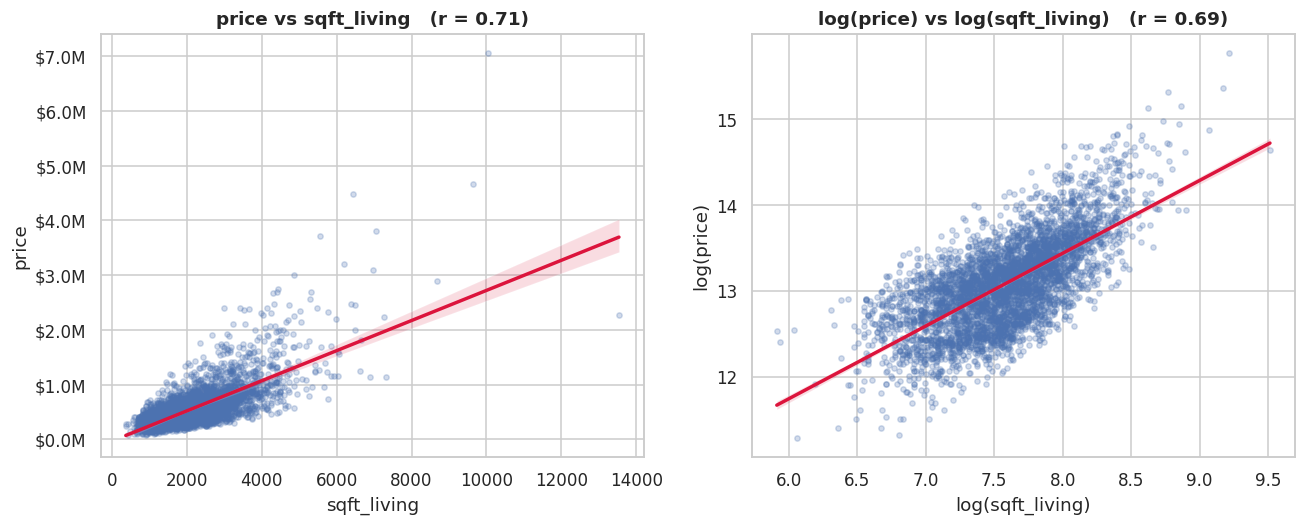

Pearson  r = 0.714   (p = 0.0e+00)   r^2 = 0.510
Spearman r = 0.669   <- rank-based, immune to the skewed tail


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x="sqft_living", y="price", ax=axes[0],
            scatter_kws={"alpha": .25, "s": 12}, line_kws={"color": "crimson"})
axes[0].set_title(f"price vs sqft_living   (r = {df['sqft_living'].corr(df['price']):.2f})")
axes[0].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.1f}M")

sns.regplot(x=np.log(df["sqft_living"]), y=df["log_price"], ax=axes[1],
            scatter_kws={"alpha": .25, "s": 12}, line_kws={"color": "crimson"})
axes[1].set_title(f"log(price) vs log(sqft_living)   (r = {np.corrcoef(np.log(df['sqft_living']), df['log_price'])[0,1]:.2f})")
axes[1].set_xlabel("log(sqft_living)")
axes[1].set_ylabel("log(price)")

save(fig, "04_sqft_vs_price")
plt.show()

pear = stats.pearsonr(df["sqft_living"], df["price"])
spear = stats.spearmanr(df["sqft_living"], df["price"])
print(f"Pearson  r = {pear[0]:.3f}   (p = {pear[1]:.1e})   r^2 = {pear[0]**2:.3f}")
print(f"Spearman r = {spear[0]:.3f}   <- rank-based, immune to the skewed tail")

### Reading it

The left panel shows the relationship clearly, but also shows the problem: the points **fan out**
as houses get bigger. At 1,500 sqft prices cluster tightly; at 5,000 sqft they range from under
$1M to over $4M. That widening spread is **`heteroscedasticity`** — non-constant residual variance,
and a direct violation of an OLS assumption.

The right panel is the same data in logs. The fan closes considerably: the spread is now roughly
constant across the range. This is the visual version of yesterday's argument, and it is a good
slide.

**Pearson 0.71 vs Spearman 0.67**: they agree, so the relationship is not an artefact of a few
extreme houses. When these two diverge sharply, the tail is doing the work — worth checking every
time.

**Slope in log-log space is an elasticity.** A coefficient of about 0.8 on log(sqft_living) means
a 10% larger house sells for roughly 8% more — *less than proportional*. Doubling floor area does
not double the price. That single sentence is more useful to a manager than any r² value.

---
## 5. Location: the driver that is not in the correlation table

`city` and `zipcode` are categorical, so they never appear in a heatmap. That does not make them
weak — in real estate they are usually the strongest signal of all. We measure them with
**median price per square foot**, which strips out house size and leaves location and quality.

**Why medians and not means:** one $7M sale would drag a city's mean anywhere. **Why a minimum
sample size:** a zip code with 4 sales gives a number you cannot defend in a viva.

In [7]:
MIN_N = 30

zips = (df.groupby("zipcode")
          .agg(sales=("price", "size"),
               median_pps=("price_per_sqft", "median"),
               median_price=("price", "median"),
               median_sqft=("sqft_living", "median"),
               city=("city", lambda s: s.mode().iat[0]))
          .query("sales >= @MIN_N")
          .sort_values("median_pps", ascending=False))

print(f"Zip codes with at least {MIN_N} sales: {len(zips)} of {df['zipcode'].nunique()}")
print()
print("TOP 8 — most expensive per square foot")
display(zips.head(8))
print("BOTTOM 8 — cheapest per square foot")
display(zips.tail(8))

Zip codes with at least 30 sales: 58 of 77

TOP 8 — most expensive per square foot


,sales,median_pps,median_price,median_sqft,city
zipcode,,,,,
98109,30,458.21,"892,500.00","2,455.00",Seattle
98004,68,450.54,"1,105,000.00","2,755.00",Bellevue
98112,67,422.41,"831,000.00","2,050.00",Seattle
98119,46,410.64,"780,000.00","2,070.00",Seattle
98105,45,392.19,"763,101.00","2,100.00",Seattle
98107,58,372.26,"515,000.00","1,450.00",Seattle
98040,75,359.09,"970,500.00","3,040.00",Mercer Island
98122,65,351.79,"599,000.00","1,540.00",Seattle


BOTTOM 8 — cheapest per square foot


,sales,median_pps,median_price,median_sqft,city
zipcode,,,,,
98042,92,155.85,"290,500.00","1,945.00",Kent
98031,59,155.33,"279,950.00","1,880.00",Kent
98003,47,152.14,"257,500.00","1,870.00",Federal Way
98030,35,150.00,"280,000.00","1,890.00",Kent
98092,80,148.24,"326,000.00","2,250.00",Auburn
98023,89,143.68,"266,000.00","1,920.00",Federal Way
98001,63,143.29,"248,000.00","1,770.00",Auburn
98002,34,142.25,"231,051.50","1,595.00",Auburn


saved -> ../reports/figures/04_zipcode_price_per_sqft.png


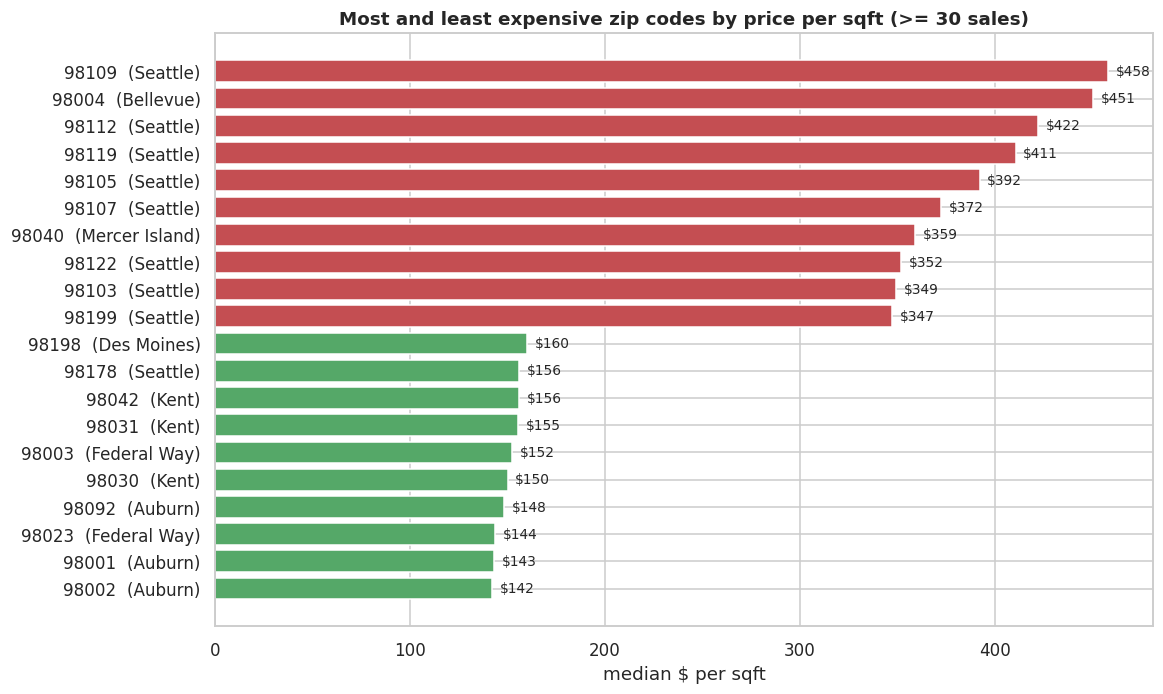

Spread: $458/sqft  vs  $142/sqft
Ratio : 3.2x


In [8]:
top_bottom = pd.concat([zips.head(10), zips.tail(10)])
colors = ["#C44E52"] * 10 + ["#55A868"] * 10

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_bottom.index.astype(str) + "  (" + top_bottom["city"] + ")",
        top_bottom["median_pps"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("median $ per sqft")
ax.set_title(f"Most and least expensive zip codes by price per sqft (>= {MIN_N} sales)")
for i, v in enumerate(top_bottom["median_pps"]):
    ax.text(v + 4, i, f"${v:,.0f}", va="center", fontsize=9)

save(fig, "04_zipcode_price_per_sqft")
plt.show()

print(f"Spread: ${zips['median_pps'].max():,.0f}/sqft  vs  ${zips['median_pps'].min():,.0f}/sqft")
print(f"Ratio : {zips['median_pps'].max() / zips['median_pps'].min():.1f}x")

In [9]:
cities = (df.groupby("city")
            .agg(sales=("price", "size"),
                 median_pps=("price_per_sqft", "median"),
                 median_price=("price", "median"),
                 median_sqft=("sqft_living", "median"))
            .query("sales >= 50")
            .sort_values("median_pps", ascending=False))

cities["rank_by_pps"]   = cities["median_pps"].rank(ascending=False).astype(int)
cities["rank_by_price"] = cities["median_price"].rank(ascending=False).astype(int)
cities["rank_gap"]      = cities["rank_by_price"] - cities["rank_by_pps"]
cities

,sales,median_pps,median_price,median_sqft,rank_by_pps,rank_by_price,rank_gap
city,,,,,,,
Mercer Island,75,359.09,"970,500.00","3,040.00",1,1,0
Seattle,1493,314.05,"496,752.00","1,660.00",2,9,7
Bellevue,265,303.00,"744,500.00","2,450.00",3,2,-1
Redmond,227,274.75,"638,000.00","2,380.00",4,4,0
Kirkland,180,274.39,"523,500.00","2,010.00",5,8,3
Issaquah,182,258.48,"563,000.00","2,245.00",6,6,0
Sammamish,160,247.69,"671,225.00","2,785.00",7,3,-4
Shoreline,118,233.93,"365,250.00","1,700.00",8,11,3
Woodinville,109,232.86,"570,000.00","2,550.00",9,5,-4


### The finding worth putting on a slide

**Location moves price per square foot by roughly 3×** across the county — from about $145/sqft in
the southern suburbs (Auburn, Federal Way, Kent) to over $450/sqft in central Seattle and Bellevue
zip codes. No physical feature of a house comes close to that range. **Location is the dominant
price driver in this dataset.**

**Now look at the `rank_gap` column.** It compares each city's rank by total price against its rank
by price per square foot:

- **Seattle** ranks mid-table on total price but near the top on price-per-sqft — it sells *small*
  homes at a *high* rate. Buying there means paying a premium for land, not for space.
- **Redmond and Sammamish** rank high on total price but noticeably lower on price-per-sqft — you
  are buying square footage, not scarcity.
- **Mercer Island** tops both. It is genuinely the most expensive place, on either measure.

That gap is the entire "where is the value?" question for Day 5, and you now have a number for it.

> **Day 6 preview:** this table is the basis of `zip_median_price_per_sqft` target encoding — and
> it must be computed on the **training set only**. Computing it on all the data leaks test
> information into your features. Note it now.

---
## 6. The waterfront premium — and how to report it honestly

In [10]:
wf = df.groupby("waterfront").agg(
    n=("price", "size"),
    median_price=("price", "median"),
    median_pps=("price_per_sqft", "median"),
    median_sqft=("sqft_living", "median"),
    median_view=("view", "median"),
)
display(wf)

premium_price = wf.loc[1, "median_price"] / wf.loc[0, "median_price"] - 1
premium_pps   = wf.loc[1, "median_pps"]   / wf.loc[0, "median_pps"]   - 1
print(f"Raw premium on price          : {premium_price:+.0%}")
print(f"Premium on price per sqft     : {premium_pps:+.0%}   <- size removed")
print(f"Sample size                   : {int(wf.loc[1, 'n'])} waterfront homes ({wf.loc[1,'n']/len(df):.1%})")

,n,median_price,median_pps,median_sqft,median_view
waterfront,,,,,
0,4316,"469,925.00",246.92,"1,970.00",0.00
1,29,"1,150,000.00",479.94,"2,810.00",4.00


Raw premium on price          : +145%
Premium on price per sqft     : +94%   <- size removed
Sample size                   : 29 waterfront homes (0.7%)


saved -> ../reports/figures/04_waterfront_and_view.png


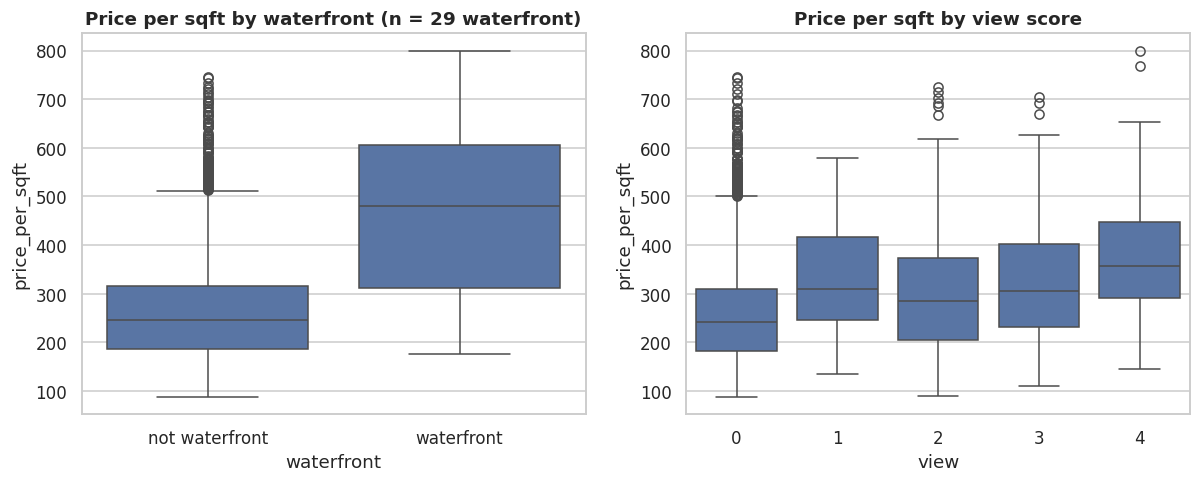

,n,median_price,median_pps
view,,,
0,3914,"450,000.00",242.11
1,66,"752,500.00",309.93
2,193,"678,500.00",285.79
3,111,"970,000.00",305.12
4,61,"1,175,000.00",358.02


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="waterfront", y="price_per_sqft", ax=axes[0])
axes[0].set_title(f"Price per sqft by waterfront (n = {int(wf.loc[1,'n'])} waterfront)")
axes[0].set_xticklabels(["not waterfront", "waterfront"])

sns.boxplot(data=df, x="view", y="price_per_sqft", ax=axes[1])
axes[1].set_title("Price per sqft by view score")

save(fig, "04_waterfront_and_view")
plt.show()

df.groupby("view").agg(n=("price", "size"),
                       median_price=("price", "median"),
                       median_pps=("price_per_sqft", "median"))

### How to say this correctly

The raw number is dramatic — waterfront homes sell for roughly **2.4× the median price**. But the
table above shows two confounders sitting right next to it:

1. Waterfront homes are **larger** (median ~2,810 vs ~1,970 sqft).
2. Every waterfront home also has a **top view score** — the two variables are almost the same
   variable here.

Switching to price-per-sqft removes the size effect and the premium drops to roughly **+94%** —
still large, still real, but half the headline. And it rests on **29 houses**, 0.7% of the data.

**The defensible sentence for your report:**

> *Waterfront properties carry a premium of roughly 90% on a per-square-foot basis. This is based
> on only 29 sales (0.7% of the dataset) and cannot be separated from the view score, which is at
> its maximum for every waterfront home. Treat it as a directional finding, not a precise figure.*

That sentence gets you Analytical Thinking marks. "Waterfront adds 140%" gets you a follow-up
question you cannot answer.

**`view` itself is the cleaner signal**: it has four non-zero levels, more rows behind it, and the
median price rises monotonically across them. Prefer it in the model.

---
## 7. Condition — a lesson in confounding

The heatmap gave `condition` a correlation with price of about **0.05**. Effectively zero. Does
condition really not matter?

Look at the group medians before you answer.

In [12]:
cond = df.groupby("condition").agg(
    n=("price", "size"),
    median_price=("price", "median"),
    median_pps=("price_per_sqft", "median"),
    median_age=("house_age", "median"),
    median_sqft=("sqft_living", "median"),
)
cond

,n,median_price,median_pps,median_age,median_sqft
condition,,,,,
1,5,"365,000.00",261.11,86.00,"1,660.00"
2,30,"250,000.00",191.85,65.50,"1,335.00"
3,2730,"474,400.00",239.65,25.00,"2,040.00"
4,1173,"450,000.00",253.27,52.00,"1,880.00"
5,407,"563,000.00",291.10,67.00,"1,980.00"


Now the pattern is not "no effect" — it is **not monotonic**. Condition 3 has a *higher* median
price than condition 4. And look at `median_age`: condition-3 houses have a median age of 25 years,
condition-5 houses 67 years.

**That is the confounder.** `condition` is an assessor's rating *relative to the age of the
building*. A 1920 Seattle house in "excellent condition" is a well-maintained old house — it is not
the same product as a 1995 suburban house rated "average". The rating is entangled with age, and
age is entangled with location: **87% of the houses over 75 years old are in Seattle**, versus 8%
of houses aged 26–50.

So the raw comparison is really comparing neighbourhoods, not maintenance.

**The fix: compare like with like.** Hold location constant by looking only inside Seattle.

,all houses,Seattle only,houses over 50 yrs,n (all)
condition,,,,
1,261.10,272.20,261.10,5
2,191.80,241.60,200.00,30
3,239.70,305.40,276.40,2730
4,253.30,323.90,292.50,1173
5,291.10,346.80,311.10,407


saved -> ../reports/figures/04_condition_confounding.png


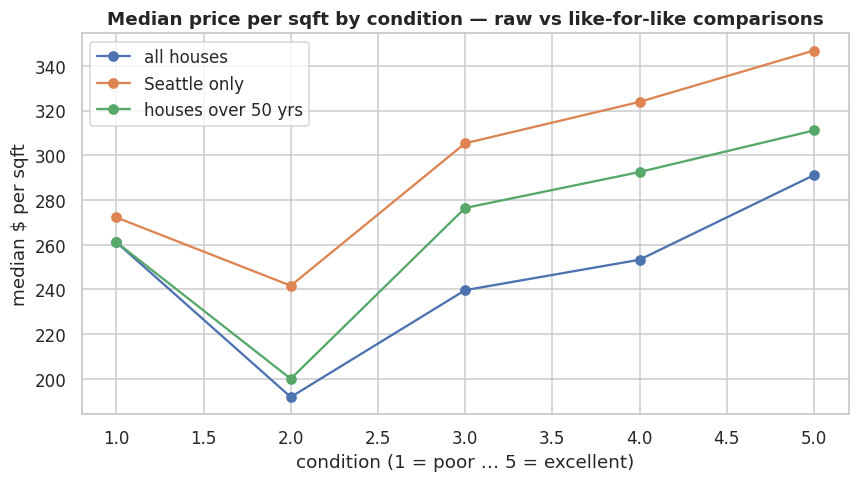

In [13]:
seattle = df[df["city"] == "Seattle"]
old     = df[df["house_age"] > 50]

comparison = pd.DataFrame({
    "all houses":            df.groupby("condition")["price_per_sqft"].median(),
    "Seattle only":          seattle.groupby("condition")["price_per_sqft"].median(),
    "houses over 50 yrs":    old.groupby("condition")["price_per_sqft"].median(),
    "n (all)":               df.groupby("condition")["price"].size(),
})
display(comparison.round(1))

fig, ax = plt.subplots(figsize=(9, 4.5))
comparison[["all houses", "Seattle only", "houses over 50 yrs"]].plot(marker="o", ax=ax)
ax.set_title("Median price per sqft by condition — raw vs like-for-like comparisons")
ax.set_xlabel("condition (1 = poor … 5 = excellent)")
ax.set_ylabel("median $ per sqft")

save(fig, "04_condition_confounding")
plt.show()

### The result

Within Seattle alone, price per square foot rises **monotonically** with condition — roughly
$305 → $324 → $347 for conditions 3, 4 and 5. The same holds among houses over 50 years old.

**Condition does matter. The raw correlation hid it because age and location moved in the opposite
direction.** This is a textbook confounder, close to Simpson's paradox, and it is happening in your
own data — which makes it a far better slide than a definition copied from Wikipedia.

> **The general lesson, and the one to repeat in your defense:** a low correlation does not prove
> "no relationship". It proves "no *linear, unconditional* relationship". Always ask what else
> differs between the groups you are comparing.

**Caveat to keep:** conditions 1 and 2 hold 5 and 30 houses. Ignore their medians entirely.

---
## 8. House age — the U-shape the heatmap could not see

`house_age` correlates with price at −0.02. On the heatmap that reads as "irrelevant".

,n,median_price,median_pps,median_sqft,pct_seattle
age_band,,,,,
0-10 yrs,723,"502,000.00",248.30,"2,303.00",38.00
11-25,775,"535,000.00",219.20,"2,440.00",10.80
26-50,1160,"440,000.00",226.00,"2,000.00",7.80
51-75,1039,"400,000.00",259.50,"1,650.00",46.00
76+,648,"550,000.00",336.90,"1,710.00",87.20


saved -> ../reports/figures/04_house_age.png


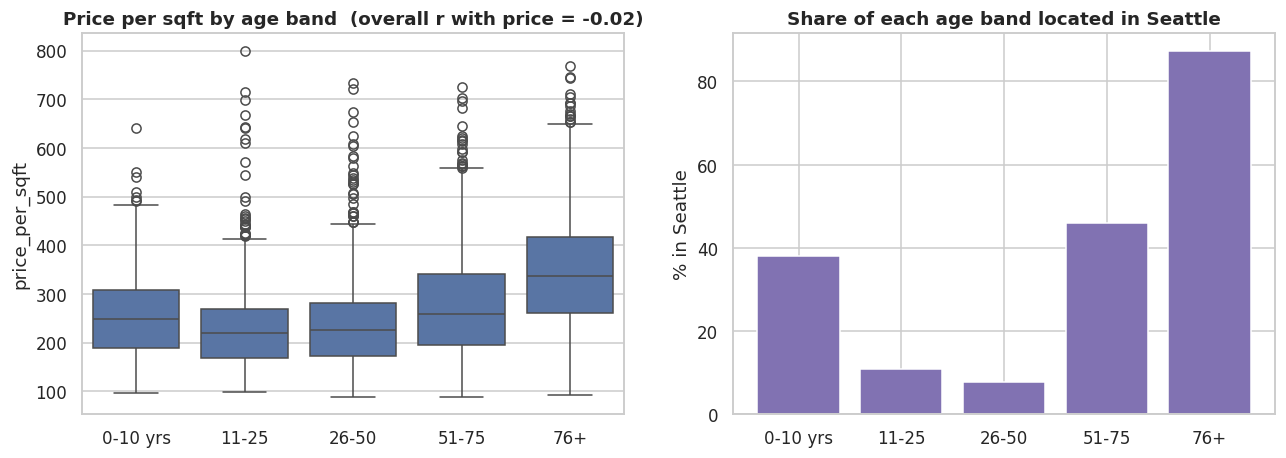

In [14]:
bins   = [-1, 10, 25, 50, 75, 200]
labels = ["0-10 yrs", "11-25", "26-50", "51-75", "76+"]
df["age_band"] = pd.cut(df["house_age"], bins=bins, labels=labels)

age_tbl = df.groupby("age_band", observed=True).agg(
    n=("price", "size"),
    median_price=("price", "median"),
    median_pps=("price_per_sqft", "median"),
    median_sqft=("sqft_living", "median"),
    pct_seattle=("city", lambda s: (s == "Seattle").mean() * 100),
)
display(age_tbl.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="age_band", y="price_per_sqft", ax=axes[0])
axes[0].set_title(f"Price per sqft by age band  (overall r with price = {df['house_age'].corr(df['price']):.2f})")
axes[0].set_xlabel("")

axes[1].bar(age_tbl.index.astype(str), age_tbl["pct_seattle"], color="#8172B2")
axes[1].set_title("Share of each age band located in Seattle")
axes[1].set_ylabel("% in Seattle")

save(fig, "04_house_age")
plt.show()

### Reading it

Price per square foot is **U-shaped in age**: new houses are expensive, 26–50 year old houses are
the cheapest, and houses over 75 years old are the **most** expensive per square foot of any band.

A Pearson correlation fits a straight line through a U and returns approximately zero. The
relationship was always there; the metric could not see it.

**But the cause is not age.** The right-hand panel gives it away: **87% of the 76+ band is in
Seattle**, against 8% of the 26–50 band. The oldest housing stock is in the urban core, which is
the most expensive land. Age is acting as a proxy for location.

**How to state it:** *"Older houses show a higher price per square foot, but this is a location
effect — the pre-war stock sits in central Seattle. Age itself is not a premium."*

**Consequence for Day 6:** a tree model can learn a U-shape on its own; a linear model cannot. If
you want `age` to work in Ridge or Lasso, give it an age *band* (or a squared term), not the raw
number. Write that into your feature plan.

---
## 9. Bedrooms: more is not better

One more counter-intuitive result, and a useful one for the business audience.

In [15]:
mid = df[df["sqft_living"].between(1800, 2400)]

by_bed = (mid[mid["bedrooms"].between(2, 5)]
          .groupby("bedrooms")
          .agg(n=("price", "size"), median_price=("price", "median"),
               median_sqft=("sqft_living", "median")))
print("Houses of similar size only (1,800-2,400 sqft) — size held roughly constant:")
display(by_bed)

print(f"corr(bedrooms, price)          = {df['bedrooms'].corr(df['price']):+.3f}")
print(f"corr(bedrooms, price_per_sqft) = {df['bedrooms'].corr(df['price_per_sqft']):+.3f}   <- negative")

Houses of similar size only (1,800-2,400 sqft) — size held roughly constant:


,n,median_price,median_sqft
bedrooms,,,
2.00,38,"622,500.00","2,050.00"
3.00,539,"489,200.00","2,015.00"
4.00,494,"450,000.00","2,100.00"
5.00,75,"420,000.00","2,130.00"


corr(bedrooms, price)          = +0.338
corr(bedrooms, price_per_sqft) = -0.212   <- negative


Across the whole dataset `bedrooms` correlates **positively** with price (+0.34), because more
bedrooms means a bigger house. But among houses of *the same size*, the median price **falls** as
bedroom count rises: ~$489k for 3 beds, ~$450k for 4, ~$420k for 5.

Correspondingly, `corr(bedrooms, price_per_sqft)` is **−0.21**.

**Interpretation:** given a fixed floor area, chopping it into more rooms makes the house *less*
valuable, not more. Buyers pay for space, not for partitions.

**The business version of that sentence:** *"Adding a bedroom by subdividing existing space
reduces value. Adding a bedroom by extending the house increases it — because you are buying
square footage, and square footage is what the market pays for."* That is a Day 5 recommendation,
already written.

---
## 10. Top 5 price drivers — with the evidence

This is the deliverable. Every row is a claim, a number, and the chart that supports it.

In [16]:
drivers = pd.DataFrame([
    {"rank": 1, "driver": "Location (zipcode / city)",
     "evidence": "Median price/sqft ranges ~$145 to ~$458 across zip codes with 30+ sales",
     "strength": "~3.2x spread", "figure": "04_zipcode_price_per_sqft"},
    {"rank": 2, "driver": "Living area (sqft_living)",
     "evidence": "r = 0.71 with price; r^2 = 0.51 — strongest single numeric predictor",
     "strength": "r = 0.71", "figure": "04_sqft_vs_price"},
    {"rank": 3, "driver": "View / waterfront",
     "evidence": "Median price/sqft rises $242 -> $358 across view 0->4; waterfront +94% (n=29)",
     "strength": "+48% (view), +94% (waterfront)", "figure": "04_waterfront_and_view"},
    {"rank": 4, "driver": "Condition (like-for-like)",
     "evidence": "Within Seattle, median price/sqft rises $305 -> $324 -> $347 for condition 3/4/5",
     "strength": "+14% (cond 3 -> 5)", "figure": "04_condition_confounding"},
    {"rank": 5, "driver": "Basement / above-ground split",
     "evidence": "r(sqft_above, price) = 0.61 vs r(sqft_basement, price) = 0.35 — above-ground space is worth more",
     "strength": "0.61 vs 0.35", "figure": "04_correlation_heatmap"},
])
drivers.set_index("rank")

,driver,evidence,strength,figure
rank,,,,
1,Location (zipcode / city),Median price/sqft ranges ~$145 to ~$458 across...,~3.2x spread,04_zipcode_price_per_sqft
2,Living area (sqft_living),r = 0.71 with price; r^2 = 0.51 — strongest si...,r = 0.71,04_sqft_vs_price
3,View / waterfront,Median price/sqft rises $242 -> $358 across vi...,"+48% (view), +94% (waterfront)",04_waterfront_and_view
4,Condition (like-for-like),"Within Seattle, median price/sqft rises $305 -...",+14% (cond 3 -> 5),04_condition_confounding
5,Basement / above-ground split,"r(sqft_above, price) = 0.61 vs r(sqft_basement...",0.61 vs 0.35,04_correlation_heatmap


In [17]:
# Sanity-check the numbers quoted above rather than trusting the table
print("1. zip pps spread   :", f"${zips['median_pps'].min():,.0f} -> ${zips['median_pps'].max():,.0f}",
      f"({zips['median_pps'].max()/zips['median_pps'].min():.2f}x)")
print("2. r(sqft_living)   :", round(df["sqft_living"].corr(df["price"]), 3),
      " r^2 =", round(df["sqft_living"].corr(df["price"])**2, 3))
v = df.groupby("view")["price_per_sqft"].median()
print("3. view 0 -> 4 pps  :", f"${v.loc[0]:,.0f} -> ${v.loc[4]:,.0f}", f"({v.loc[4]/v.loc[0]-1:+.0%})")
s = seattle.groupby("condition")["price_per_sqft"].median()
print("4. Seattle cond 3->5:", f"${s.loc[3]:,.0f} -> ${s.loc[5]:,.0f}", f"({s.loc[5]/s.loc[3]-1:+.0%})")
print("5. above vs basement:", round(df["sqft_above"].corr(df["price"]), 3), "vs",
      round(df["sqft_basement"].corr(df["price"]), 3))

1. zip pps spread   : $142 -> $458 (3.22x)
2. r(sqft_living)   : 0.714  r^2 = 0.51
3. view 0 -> 4 pps  : $242 -> $358 (+48%)
4. Seattle cond 3->5: $305 -> $347 (+14%)
5. above vs basement: 0.613 vs 0.345


---
## 11. What we established today

1. **Location dominates.** Median price per square foot varies about **3.2×** across zip codes —
   more than any physical attribute of the house.
2. **`sqft_living` is the strongest numeric predictor** (r = 0.71, r² = 0.51), but the relationship
   is heteroscedastic on the raw scale and much better behaved in logs. In log-log terms the
   elasticity is below 1: a 10% bigger house is ~8% more expensive, not 10%.
3. **Three redundant feature pairs exist.** `sqft_living = sqft_above + sqft_basement` is an exact
   identity — drop `sqft_above` on Day 9. `bathrooms` is mostly a size proxy (r = 0.76 with
   `sqft_living`) and must not be sold as an independent driver.
4. **The waterfront premium is ~+94% per sqft, not +140%**, once size is removed — and it rests on
   29 houses that all also have the maximum view score.
5. **`condition` and `house_age` are confounded by location.** Raw correlations of 0.05 and −0.02
   are artefacts; within Seattle, condition raises price per sqft monotonically, and the "old
   houses are expensive" effect is really "old houses are downtown".
6. **More bedrooms at constant size lowers price** (r = −0.21 with price per sqft). Buyers pay for
   space, not partitions.

### Figures saved to `reports/figures/`

`04_correlation_heatmap` · `04_sqft_vs_price` · `04_zipcode_price_per_sqft` ·
`04_waterfront_and_view` · `04_condition_confounding` · `04_house_age`

### Carried forward

| To | Note |
|---|---|
| **Day 5** | The zip-code table and the rank-gap column are the backbone of the business recommendations. |
| **Day 6** | `zip_median_price_per_sqft` must be fit on the **training set only**. Age needs banding or a squared term to be usable by a linear model. |
| **Day 9** | Drop `sqft_above`. Expect unstable coefficients on the size-related features in Ridge/Lasso and say why. |

### Before you commit

Rewrite section 11 in your own words, then answer this out loud: *"What is your strongest price
driver, and how do you know it is not just measuring house size?"*

```powershell
git add . && git commit -m "Day 4: EDA part 2 - relationships and price drivers"
```

**Next:** Day 5 — no new code. Turn these findings into business recommendations a manager can act
on.